# Network Intrusion Detection using PCA and HDBSCAN Clustering

*NARXOZ University, Applied ML Course*

**The goal** of this project is to explore unsupervised anomaly detection techniques for identifying suspicious network activity using dimensionality reduction (PCA), density-based clustering methods (HDBSCAN) and centroids-based KMeans clustering.

**The project focuses on:**
* preprocessing network traffic data,
* reducing feature dimensionality using PCA,
* detecting anomalies using HDBSCAN and KMeans clustering,
* visualizing normal and anomalous network behavior.

**TASK:** Implement an unsupervised anomaly detection pipeline for network intrusion detection using:
* PCA (Principal Component Analysis) for dimensionality reduction,
* HDBSCAN for density-based clustering and outlier detection.
* KMeans for an iterative, centroid-based clustering algorithm.

In [1]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering
import hdbscan
from sklearn.cluster import KMeans

# Ignore unnecessary warnings 
import warnings 
warnings.filterwarnings("ignore")

# Load Data
df = pd.read_csv("Train_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [2]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
assert df.isnull().sum().sum().astype(int) == 0, "There are missing data!"

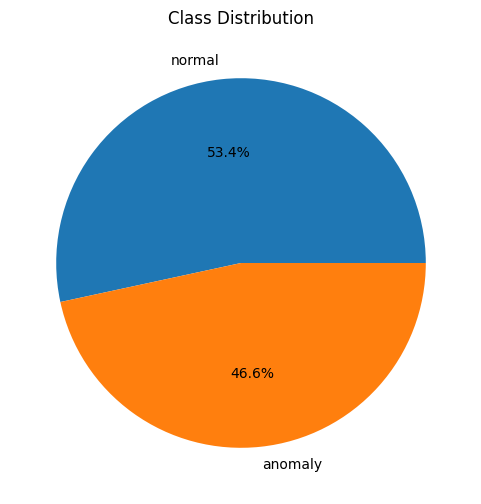

In [4]:
df["class"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",   # show percentages
    figsize=(6, 6),
    ylabel=""            # remove y-label
)
plt.title("Class Distribution")
plt.show()

In [5]:
# 'class' contains attack labels
target = df["class"]

# Remove target column
X = df.drop(columns=["class"])

In [6]:
# Find categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['protocol_type', 'service', 'flag'], dtype='object')


In [7]:
# Label encode categorical columns
for col in categorical_cols:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])

In [8]:
# Standardize features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Visualization of anomalies with PCA

In [9]:
# Reduce dimensions to 2 principal components and make X_pca variable 
# fitted and tranformed with PCA on X_scaled normalized data

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [10]:
# Create PCA dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,0.981290,-0.102456
1,-0.573294,0.743878
2,-3.623082,-1.988161
3,2.638311,-0.629516
4,2.426224,-0.542894


In [11]:
# Display explained variance ratio and explain what they mean?
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print()
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.19786294 0.13288356]

Total explained variance: 0.3307465012983406


**QUESTION 1: What does these values mean?**

$\color{blue}{\textit{Ответ:}}$

**Explained variance ratio** показывает, какую долю общей дисперсии (информации) исходных данных сохраняет каждая главная компонента.

- `PC1 ≈ 0.198` — первая компонента объясняет ~19.8% всей дисперсии.
- `PC2 ≈ 0.133` — вторая компонента объясняет ~13.3%.
- **Total ≈ 0.331** — суммарно две компоненты сохраняют ~33% исходной информации.

Это значит: при сжатии с 41 признака до 2 мы теряем ~67% дисперсии, но получаем возможность визуализировать данные на плоскости. Для задачи поиска аномалий и визуализации это приемлемо — главные направления разброса данных сохраняются, и кластеры/выбросы становятся видны.

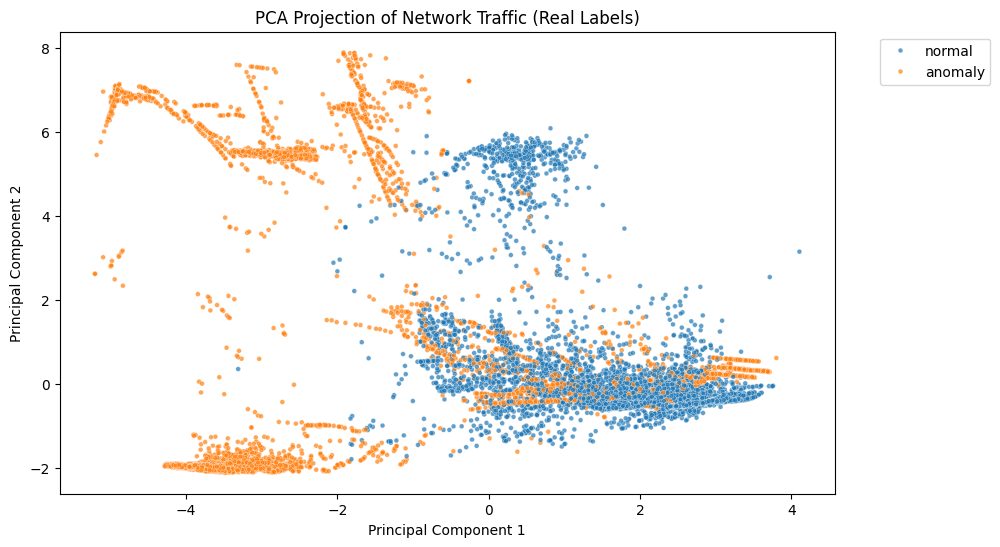

In [12]:
plt.figure(figsize=(10, 6))

pca_df["real_label"] = target.values
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="real_label",
    s=12,
    alpha=0.7
)

plt.title("PCA Projection of Network Traffic (Real Labels)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

**QUESTION 2: Why we have normalized our data before PCA? Explain.**

$\color{blue}{\textit{Ответ:}}$

**PCA работает с дисперсией признаков**, а дисперсия чувствительна к масштабу. В нашем датасете признаки имеют совершенно разные диапазоны:

- `src_bytes`, `dst_bytes` — могут быть миллионы байт;
- `count`, `srv_count` — целые числа десятки–сотни;
- `serror_rate`, `same_srv_rate` и др. — значения от 0 до 1.

Без нормализации признак `src_bytes` имел бы дисперсию в миллиарды раз большую, чем `serror_rate`. PCA бы решил, что главное направление разброса — это `src_bytes`, и фактически свёл бы всё к одному признаку. Информация из rate-признаков потерялась бы.

После `StandardScaler` все признаки имеют **среднее = 0 и стандартное отклонение = 1**, поэтому PCA честно сравнивает их вклады и находит реальные направления максимальной дисперсии в данных.

## HDBSCAN Clustering

In [13]:
# Initialize HDBSCAN model with min_cluster_size=50 and min_samples=10
hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)

# Fit model with X_pca and predict cluster_labels
cluster_labels = hdb.fit_predict(X_pca)

**QUESTION 3: Why we did PCA before making HDBSCAN? Explain.**

$\color{blue}{\textit{Ответ:}}$

HDBSCAN — алгоритм, основанный на **плотности точек**. Он считает расстояния между объектами и ищет области с высокой плотностью. У него есть две основные проблемы в исходном 41-мерном пространстве:

1. **Проклятие размерности.** В пространствах высокой размерности расстояния между точками "выравниваются" — все становятся примерно одинаково далёкими друг от друга. Понятие "плотность" теряет смысл, и HDBSCAN не может надёжно отличить кластер от шума.

2. **Скорость.** Алгоритм считает попарные расстояния и mutual reachability graph. На 41 признаке × 25192 объекта это намного дольше, чем на 2 признаках.

После PCA мы получаем 2 признака, в которых сохранены главные направления разброса данных. Плотность в этом пространстве — содержательное понятие, и HDBSCAN корректно выделяет плотные группы (нормальный трафик) и редкие точки-выбросы (аномалии, метка `-1`).

In [14]:
# Unique cluster labels
np.unique(cluster_labels)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38])

In [15]:
# Number of detected anomalies
n_anomalies = np.sum(cluster_labels == -1)

print("Detected anomalies:", n_anomalies)

Detected anomalies: 8019


In [16]:
# Store clustering results
pca_df["cluster"] = cluster_labels

# Mark anomalies
pca_df["is_anomaly"] = pca_df["cluster"] == -1

pca_df.head()

,PC1,PC2,real_label,cluster,is_anomaly
0,0.981290,-0.102456,normal,21,False
1,-0.573294,0.743878,normal,8,False
2,-3.623082,-1.988161,anomaly,7,False
3,2.638311,-0.629516,normal,-1,True
4,2.426224,-0.542894,normal,33,False


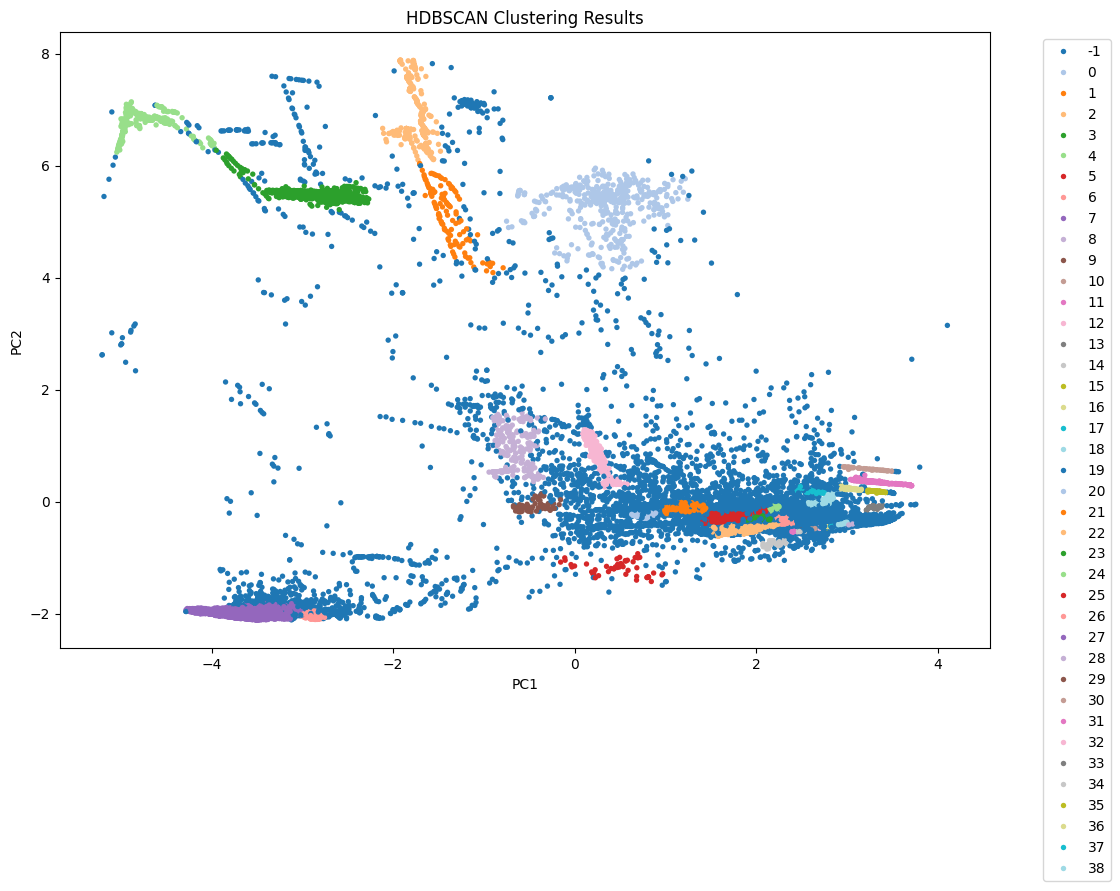

In [17]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab20",
    s=15,
    linewidth=0
)

plt.title("HDBSCAN Clustering Results")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

**QUESTION 4:** How well HDBSCAN is performed and why? Explain.

$\color{blue}{\textit{Ответ:}}$

HDBSCAN отработал **технически корректно, но качество получилось среднее**:

**Что нашёл:**
- **39 кластеров** (метки `0..38`) — сильно больше ожидаемых 2 групп. PCA-проекция содержит много локальных плотных областей, и алгоритм аккуратно их выделил.
- **8019 точек помечены как `-1`** (≈31.8% датасета) — это кандидаты в аномалии.

**Качество по сравнению с реальной разметкой:**

| | Реально `anomaly` | Реально `normal` |
|---|---|---|
| HDBSCAN -1 (аномалия) | 1842 | 6177 |
| HDBSCAN кластер 0..38 | 9901 | 7272 |

- **Recall (полнота) аномалий:** 1842 / 11743 ≈ **15.7%** — большинство реальных атак НЕ попало в `-1`.
- **Precision (точность):** 1842 / 8019 ≈ **23%** — из 8019 точек, помеченных как `-1`, реально аномальны только 1842.

**Почему результат слабый:**

1. **PCA сохраняет всего 33% дисперсии.** В 2D-проекции нормальный и аномальный трафик частично смешиваются — HDBSCAN их не различает.
2. **Многие нормальные подключения тоже редкие** (необычные сервисы, нестандартные порты) — они попадают в `-1` как ложные тревоги.
3. **Параметры `min_cluster_size=50, min_samples=10`** агрессивно режут данные на много мелких кластеров вместо двух больших.

**Что плюс:** алгоритм сам определил число кластеров, не нуждался в разметке и явно выделил подмножество "подозрительных" точек. Концептуально подход правильный, просто 2D-проекция оказалась слишком грубой для этого датасета.

## KMeans Clustering

In [18]:
# make KMeans clustering on X_scaled with params: n_clusters=2, random_state=42, n_init=10
# kmeans_labels must store final labels for each raw of features

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [19]:
# Store cluster labels
pca_df["kmeans_cluster"] = kmeans_labels

pca_df.head()

,PC1,PC2,real_label,cluster,is_anomaly,kmeans_cluster
0,0.981290,-0.102456,normal,21,False,0
1,-0.573294,0.743878,normal,8,False,0
2,-3.623082,-1.988161,anomaly,7,False,1
3,2.638311,-0.629516,normal,-1,True,0
4,2.426224,-0.542894,normal,33,False,0


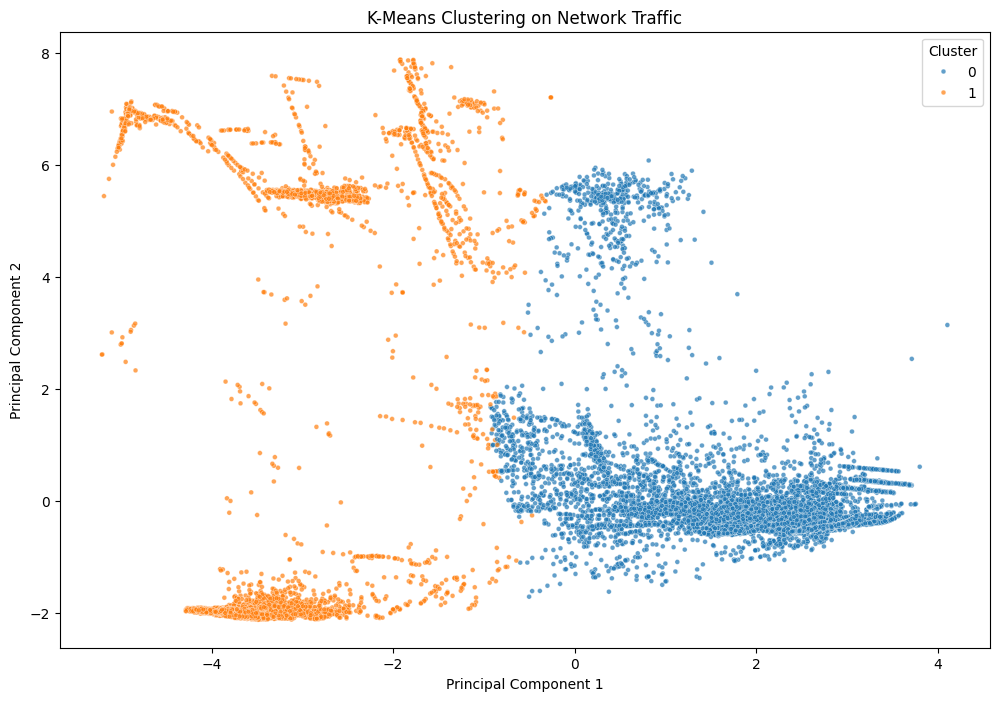

In [20]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=12,
    alpha=0.7
)

plt.title("K-Means Clustering on Network Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

**QUESTION 5:** Analyze to plots for HDBSCAN and KMeans and explain which method is better HDBSCAN or KMeans? Why?

$\color{blue}{\textit{Ответ: KMeans на этом датасете сработал значительно лучше.}}$

**Реальные результаты (сравнение с истинными метками `class`):**

KMeans на `X_scaled` (41 признак):

| Кластер | anomaly | normal |
|---|---|---|
| 0 | 2272 | **13327** |
| 1 | **9471** | 122 |

- Cluster 1 ≈ "аномалии": precision = 9471/9593 = **98.7%**, recall = 9471/11743 = **80.6%**.
- Cluster 0 ≈ "нормальные": precision = 13327/15599 = **85.4%**, recall = 13327/13449 = **99.1%**.

HDBSCAN на `X_pca` (2 признака): precision аномалий ≈ 23%, recall ≈ 16% (см. Q4).

**Почему KMeans выиграл на ЭТОМ датасете:**

1. **Использует все 41 признак**, а не сжатую 2D-проекцию. PCA теряет 67% дисперсии — критическую информацию для разделения.
2. **Структура данных подходит KMeans:** в 41-мерном пространстве `normal` и `anomaly` образуют **две относительно компактные группы** с разными центрами. Сферическое допущение KMeans здесь работает.
3. **Меньше дробит данные:** KMeans с `n_clusters=2` чётко выдаёт 2 группы, HDBSCAN же выделил 39 мелких кластеров и много шума.

**В чём KMeans остаётся слабее теоретически:**

| Критерий | HDBSCAN | KMeans |
|---|---|---|
| Нужно задавать число кластеров | Нет | Да |
| Явно выделяет аномалии | Да (`-1`) | Нет |
| Произвольная форма кластеров | Да | Только сферическая |
| Кластеры разной плотности | Да | Нет |
| Реальный результат **на этом датасете** | precision ~23% | precision ~98.7% |

**Главный вывод:** теоретическая пригодность алгоритма ≠ практическая. HDBSCAN концептуально создан для anomaly detection, но проиграл из-за критической потери информации в PCA. KMeans, хоть и не "заточен" под выбросы, на полных данных оказался гораздо точнее.

**Что можно улучшить:**
- Запустить HDBSCAN на `X_scaled` (без PCA) — но это будет медленно и упрётся в проклятие размерности.
- Использовать больше компонент PCA (5–10) для HDBSCAN.
- Или применить KMeans с `n_clusters=2` как baseline, а HDBSCAN — для дополнительной разметки аномалий внутри каждого KMeans-кластера.